In [46]:
import numpy as np
from scipy.stats import spearmanr

def spearman_ci(s1, s2, n_boot=2000, ci=0.95, seed=0):
    s1 = np.asarray(s1).ravel()
    s2 = np.asarray(s2).ravel()
    assert s1.shape == s2.shape
    n = s1.shape[0]

    rho = spearmanr(s1, s2).correlation

    rng = np.random.default_rng(seed)
    rhos = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)  # resample examples with replacement
        rhos[b] = spearmanr(s1[idx], s2[idx]).correlation

    alpha = (1 - ci) / 2
    lo = np.quantile(rhos, alpha)
    hi = np.quantile(rhos, 1 - alpha)
    return float(rho), float(lo), float(hi)


In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os
from pathlib import Path
import torch
from scipy.stats import spearmanr
from tqdm import tqdm


diffmean_root = "../projection_pca_64"

hinge_path = "pca_64/projection_pca_hinge"
logistic_path = "pca_64/projection_pca_logistic"

diffmean_files = list(Path(diffmean_root).glob("*.pt"))


spearman_corr_real = []

for file in tqdm(diffmean_files):
    diffmean = torch.load(file)

    
    result = {
        'benchmark': diffmean['benchmark'],
        'model': diffmean['model_name'],
        'column': diffmean['column'],
    }
    model = diffmean['model_name'].split("/")[-1]
    
    benchmark = diffmean['benchmark']
    
    dataset = pd.read_csv(f"../{benchmark}.csv")
    
    indices = dataset[dataset['dataset']=='test']['id'].tolist()
    indices = np.array(indices)
    del dataset
    

    if model == "Qwen3-30B-A3B-Instruct-2507":
        continue
    if diffmean['column'] == 'longer_context':
        continue

    file_name = f"{benchmark}_{diffmean['column']}_{model}"

    probe_file_name = f"{file_name}_projection.pt"

    hinge = torch.load(os.path.join(hinge_path, probe_file_name))
    logistic = torch.load(os.path.join(logistic_path, probe_file_name))

    N, num_layers = diffmean['projection'].shape
    
    
    diffmean_hinge = np.zeros((num_layers,))
    diffmean_hinge_ci = np.zeros((num_layers, 2))
    diffmean_logistic = np.zeros((num_layers,))
    diffmean_logistic_ci = np.zeros((num_layers, 2))
    hinge_logistic =  np.zeros((num_layers,))
    hinge_logistic_ci =  np.zeros((num_layers, 2))
    for layer_index in range(num_layers):
        diffmean_proj_test = diffmean['projection'][:, layer_index][indices].numpy()
        
        hinge_proj_test = hinge['projection'][:, layer_index][indices].numpy()
        logistic_proj_test = logistic['projection'][:, layer_index][indices].numpy()

        diffmean_hinge[layer_index], diffmean_hinge_ci[layer_index][0], diffmean_hinge_ci[layer_index][1] = spearman_ci(diffmean_proj_test, hinge_proj_test)
        diffmean_logistic[layer_index], diffmean_logistic_ci[layer_index][0], diffmean_logistic_ci[layer_index][1] = spearman_ci(diffmean_proj_test, logistic_proj_test)
        hinge_logistic[layer_index], hinge_logistic_ci[layer_index][0], hinge_logistic_ci[layer_index][1] = spearman_ci(hinge_proj_test, logistic_proj_test)

    result['diffmean_hinge'] = diffmean_hinge.tolist()
    result['diffmean_hinge_ci'] = diffmean_hinge_ci.tolist()
    result['diffmean_logistic'] = diffmean_logistic.tolist()
    result['diffmean_logistic_ci'] = diffmean_logistic_ci.tolist()
    result['hinge_logistic'] = hinge_logistic.tolist()
    result['hinge_logistic_ci'] = hinge_logistic_ci.tolist()

    spearman_corr_real.append(result)
    
    
with open("spearman_corr_real.json", "w") as f:
    for item in spearman_corr_real:
        f.write(json.dumps(item) + "\n")
        


100%|██████████| 30/30 [21:06<00:00, 42.23s/it]


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json
import os
from pathlib import Path
import torch
from scipy.stats import spearmanr
from tqdm import tqdm


diffmean_root = "../projection_synthetic_pca_64"

hinge_path = "pca_64/projection_synthetic_pca_hinge"
logistic_path = "pca_64/projection_synthetic_pca_logistic"

diffmean_files = list(Path(diffmean_root).glob("*.pt"))


spearman_corr_real = []

for file in tqdm(diffmean_files):
    diffmean = torch.load(file)

    
    result = {
        'benchmark': diffmean['benchmark'],
        'model': diffmean['model_name'],
        'column': diffmean['column'],
    }
    model = diffmean['model_name'].split("/")[-1]
    
    benchmark = diffmean['benchmark']
    
    dataset = pd.read_csv(f"../{benchmark}.csv")
    
    indices = dataset[dataset['dataset']=='test']['id'].tolist()
    indices = np.array(indices)
    del dataset
    

    if model == "Qwen3-30B-A3B-Instruct-2507":
        continue
    if diffmean['column'] == 'longer_context':
        continue

    file_name = f"{benchmark}_{diffmean['column']}_{model}"

    probe_file_name = f"{file_name}_projection.pt"

    hinge = torch.load(os.path.join(hinge_path, probe_file_name))
    logistic = torch.load(os.path.join(logistic_path, probe_file_name))

    N, num_layers = diffmean['projection'].shape
    
    
    diffmean_hinge = np.zeros((num_layers,))
    diffmean_hinge_ci = np.zeros((num_layers, 2))
    diffmean_logistic = np.zeros((num_layers,))
    diffmean_logistic_ci = np.zeros((num_layers, 2))
    hinge_logistic =  np.zeros((num_layers,))
    hinge_logistic_ci =  np.zeros((num_layers, 2))
    for layer_index in range(num_layers):
        diffmean_proj_test = diffmean['projection'][:, layer_index][indices].numpy()
        
        hinge_proj_test = hinge['projection'][:, layer_index][indices].numpy()
        logistic_proj_test = logistic['projection'][:, layer_index][indices].numpy()

        diffmean_hinge[layer_index], diffmean_hinge_ci[layer_index][0], diffmean_hinge_ci[layer_index][1] = spearman_ci(diffmean_proj_test, hinge_proj_test)
        diffmean_logistic[layer_index], diffmean_logistic_ci[layer_index][0], diffmean_logistic_ci[layer_index][1] = spearman_ci(diffmean_proj_test, logistic_proj_test)
        hinge_logistic[layer_index], hinge_logistic_ci[layer_index][0], hinge_logistic_ci[layer_index][1] = spearman_ci(hinge_proj_test, logistic_proj_test)

    result['diffmean_hinge'] = diffmean_hinge.tolist()
    result['diffmean_hinge_ci'] = diffmean_hinge_ci.tolist()
    result['diffmean_logistic'] = diffmean_logistic.tolist()
    result['diffmean_logistic_ci'] = diffmean_logistic_ci.tolist()
    result['hinge_logistic'] = hinge_logistic.tolist()
    result['hinge_logistic_ci'] = hinge_logistic_ci.tolist()

    spearman_corr_real.append(result)


with open("spearman_corr_synthetic.json", "w") as f:
    for item in spearman_corr_real:
        f.write(json.dumps(item) + "\n")
        


  0%|          | 0/18 [00:00<?, ?it/s]/var/folders/1d/x42w8kj57yg4hd8tjgzqc8t40000gn/T/ipykernel_40634/2479870660.py:10: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho = spearmanr(s1, s2).correlation
/var/folders/1d/x42w8kj57yg4hd8tjgzqc8t40000gn/T/ipykernel_40634/2479870660.py:16: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rhos[b] = spearmanr(s1[idx], s2[idx]).correlation
  6%|▌         | 1/18 [00:47<13:20, 47.08s/it]/var/folders/1d/x42w8kj57yg4hd8tjgzqc8t40000gn/T/ipykernel_40634/2479870660.py:10: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho = spearmanr(s1, s2).correlation
/var/folders/1d/x42w8kj57yg4hd8tjgzqc8t40000gn/T/ipykernel_40634/2479870660.py:16: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rhos[b] = spearmanr(s1[idx], s2[idx]).correlation
 11%|█         | 2/18 [02:21

In [4]:
import json
with open("spearman_corr_real.json", "r") as f:
    spearman_corr_real = [json.loads(line) for line in f.readlines()]
    
print(len(spearman_corr_real))

20


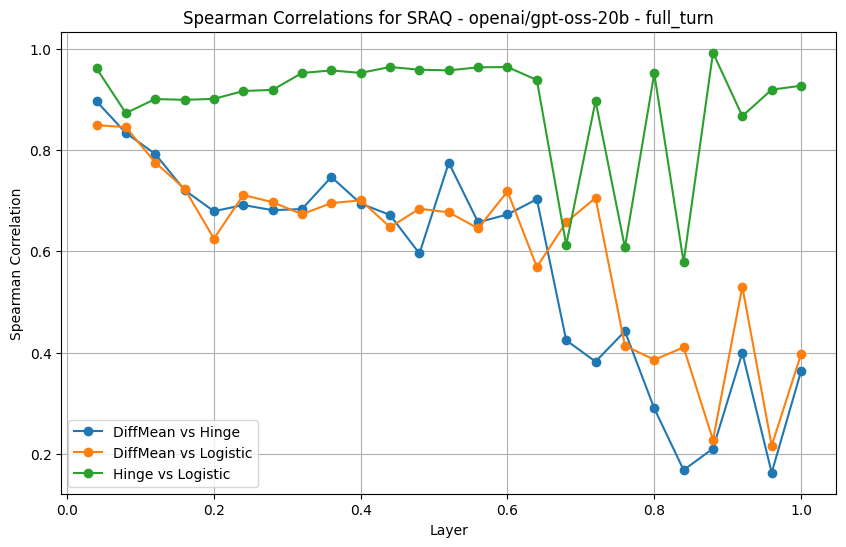

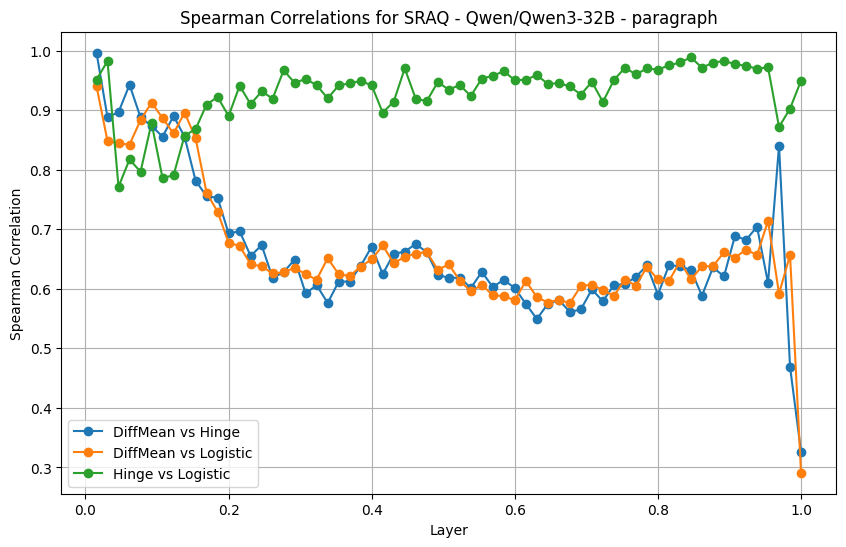

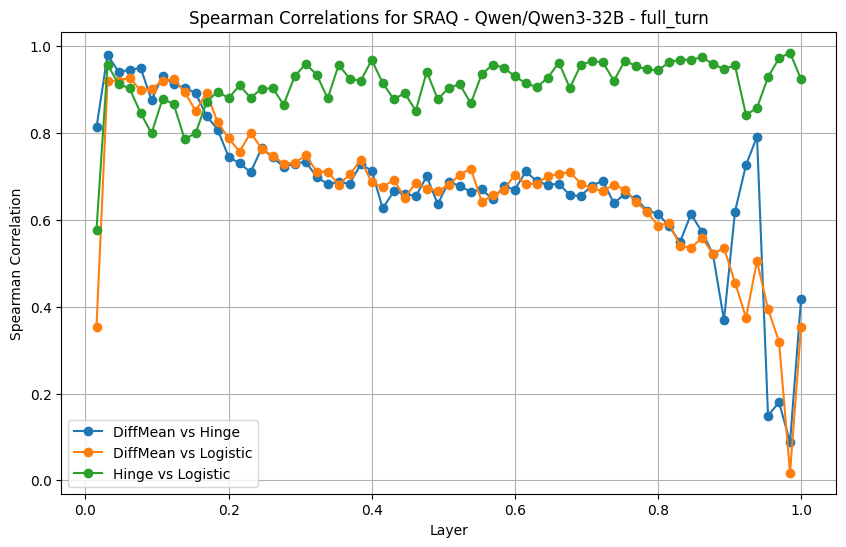

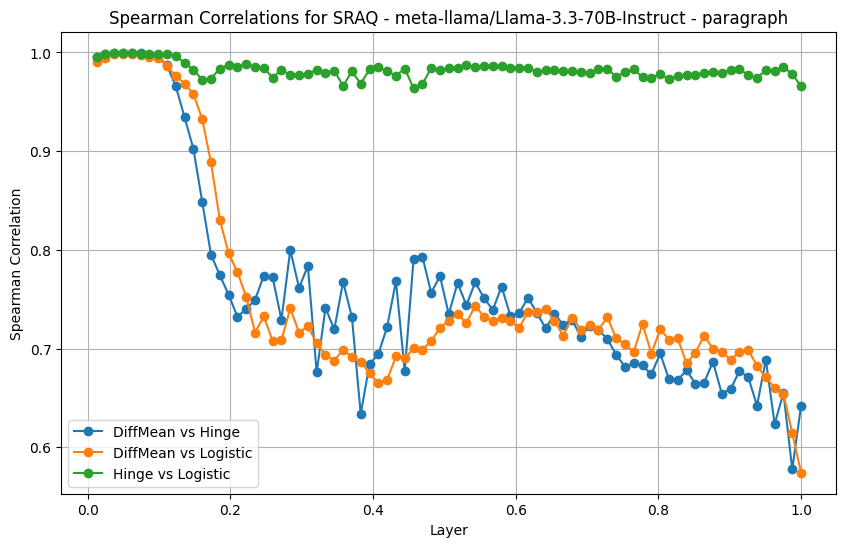

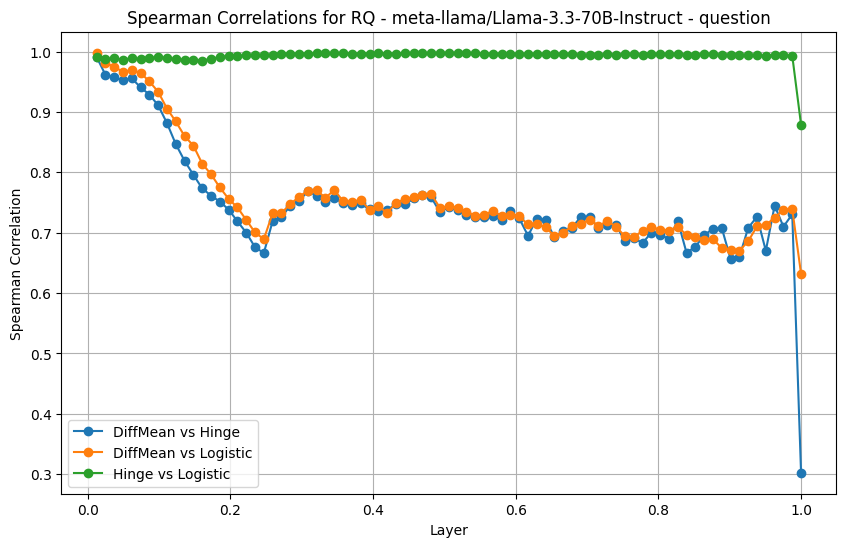

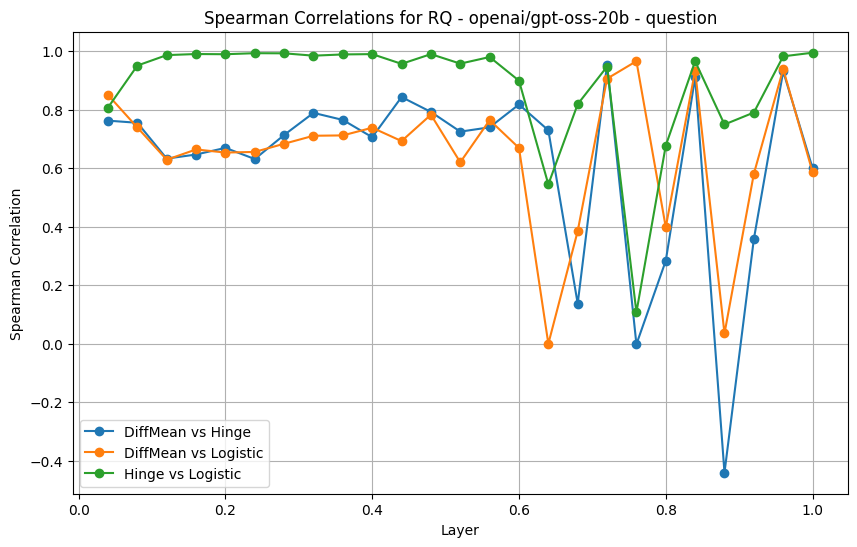

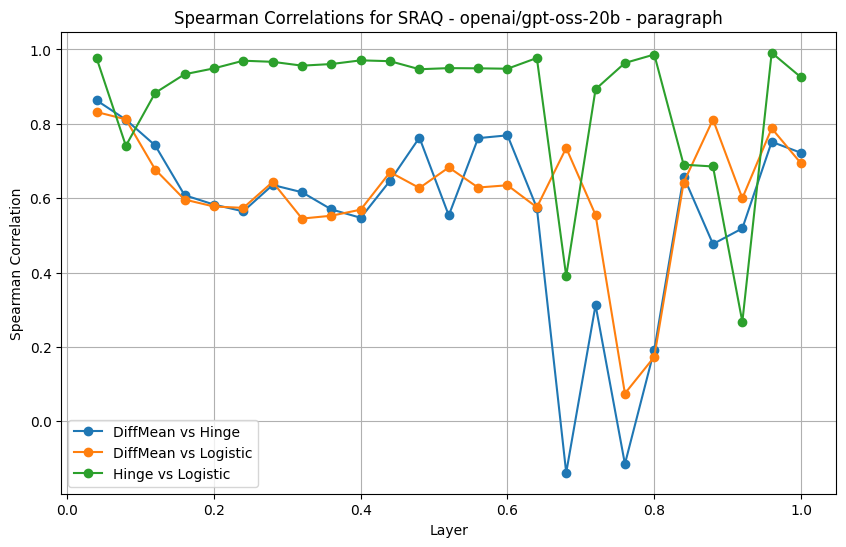

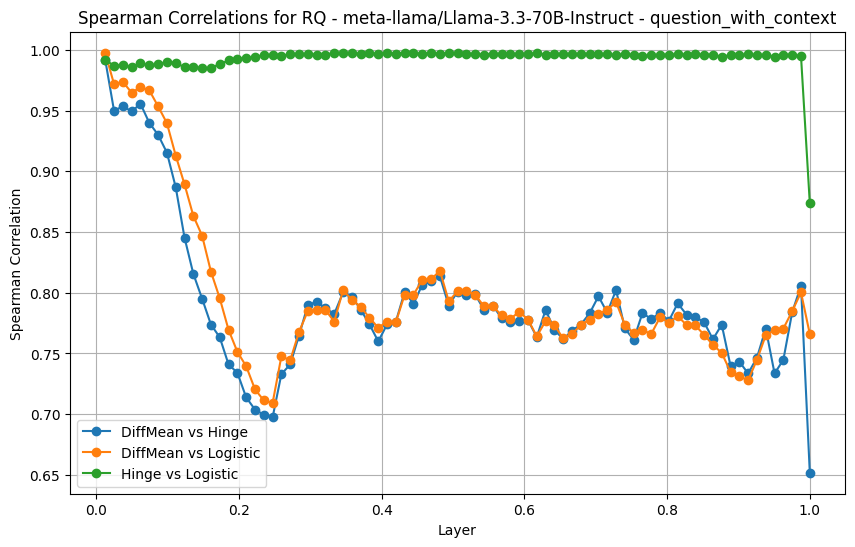

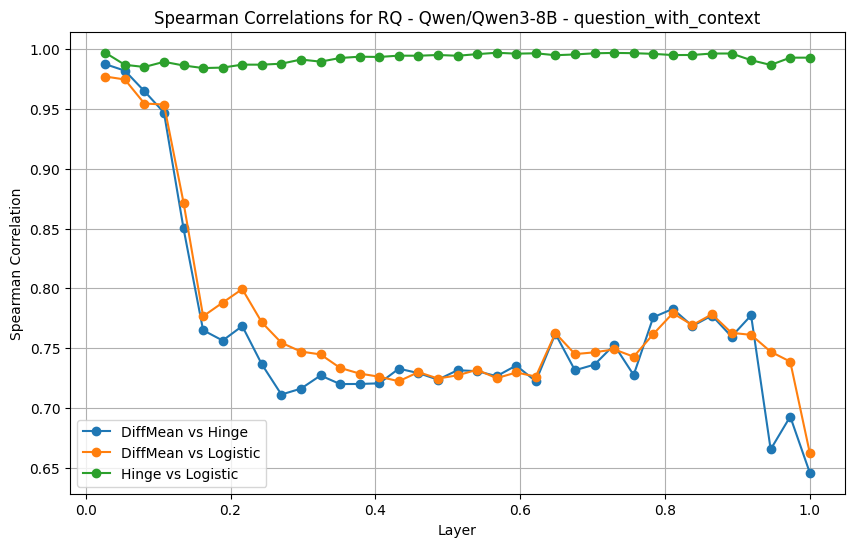

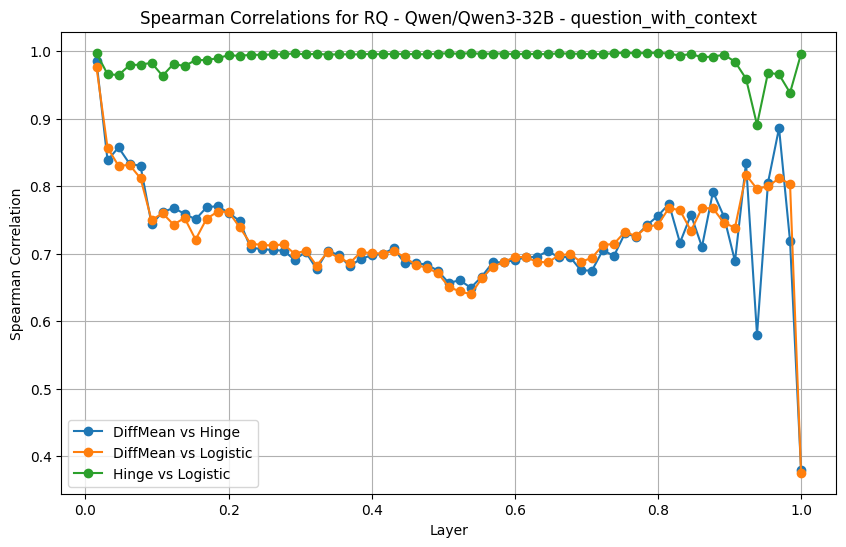

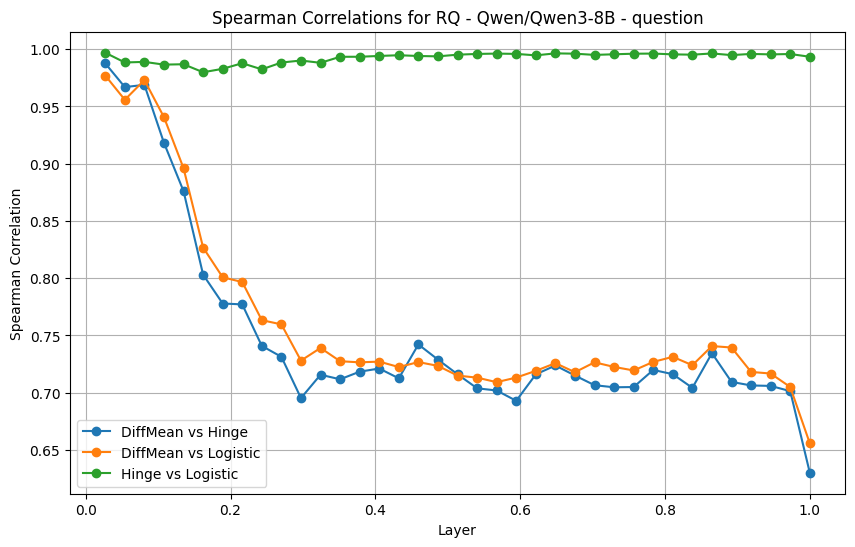

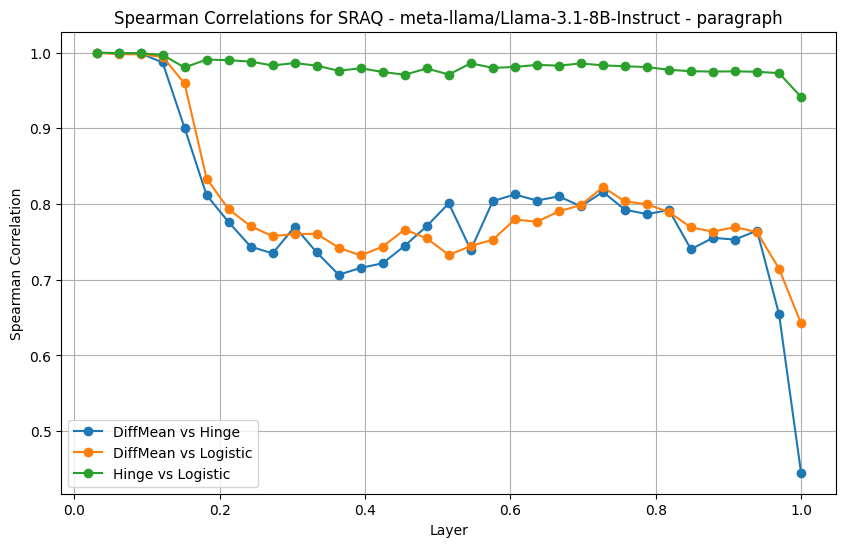

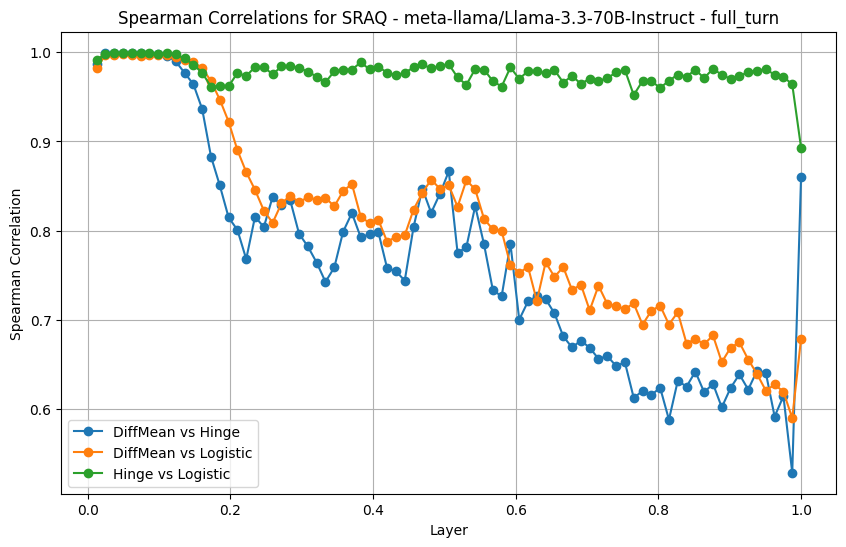

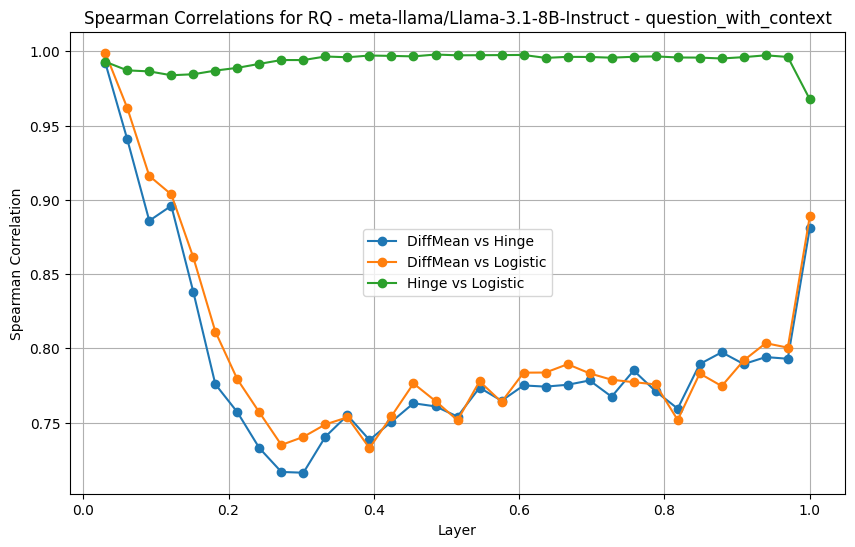

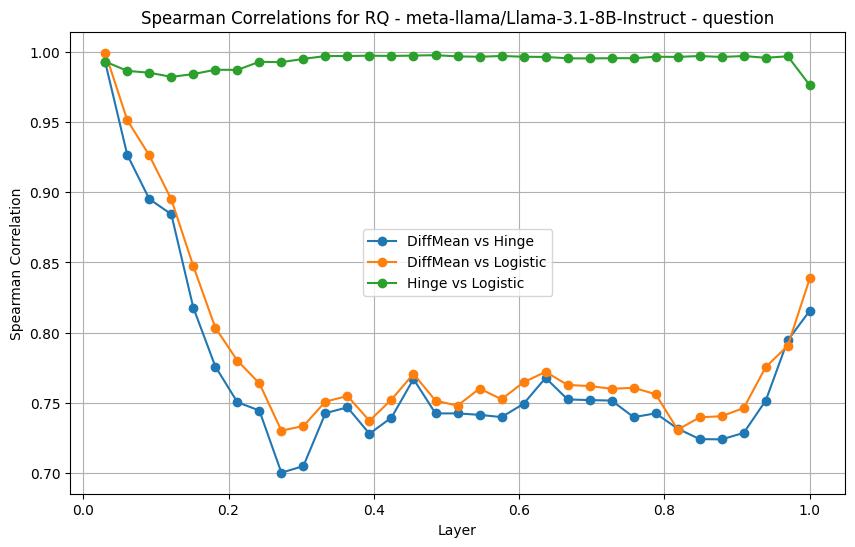

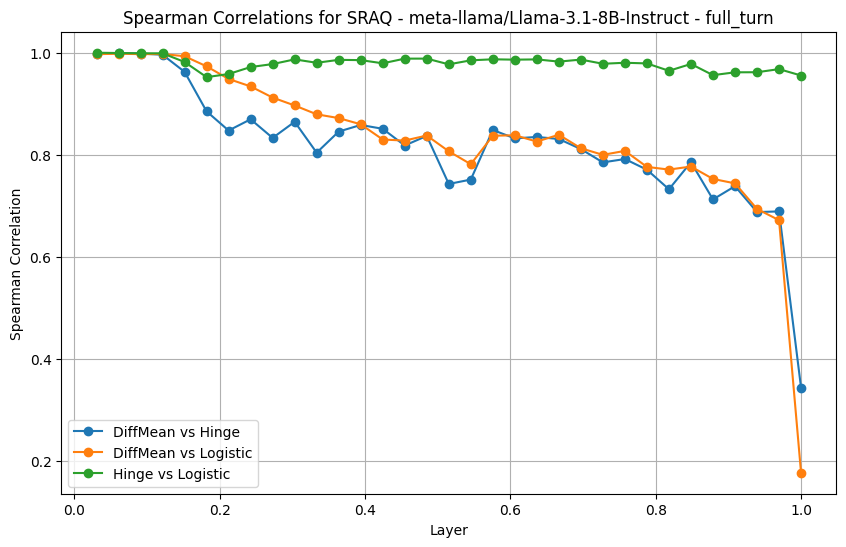

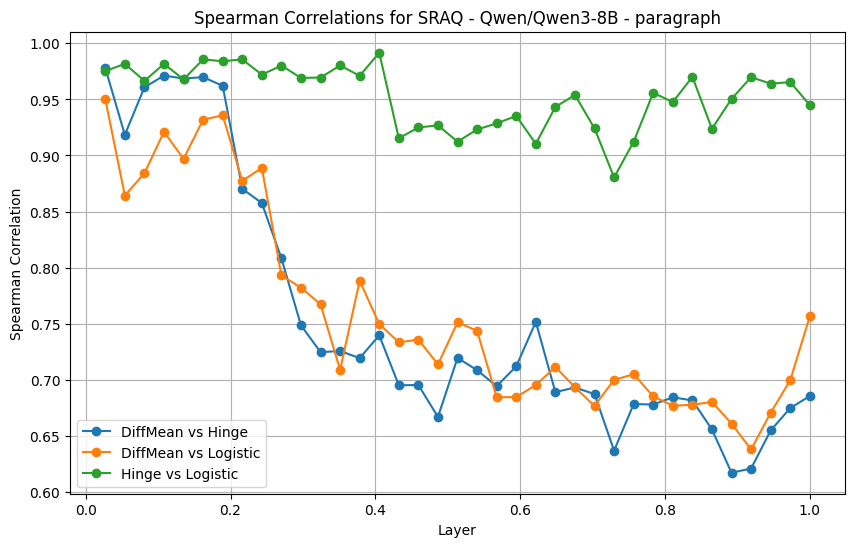

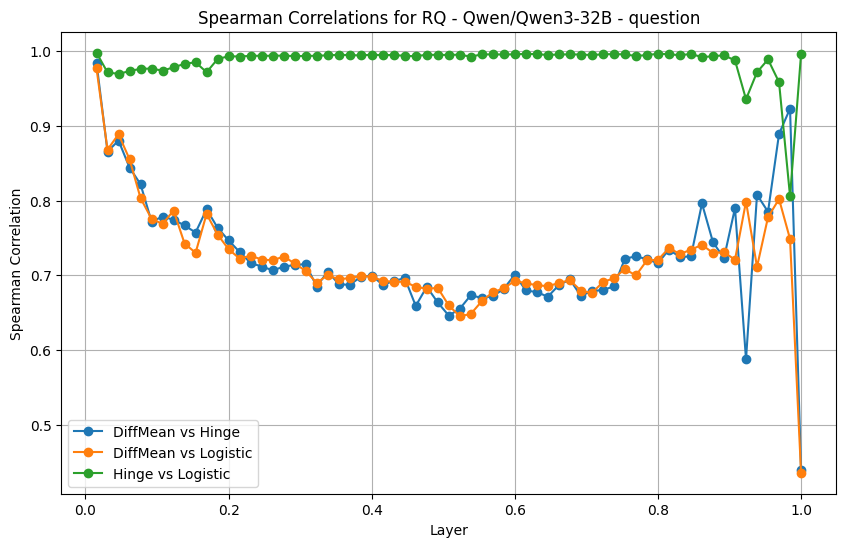

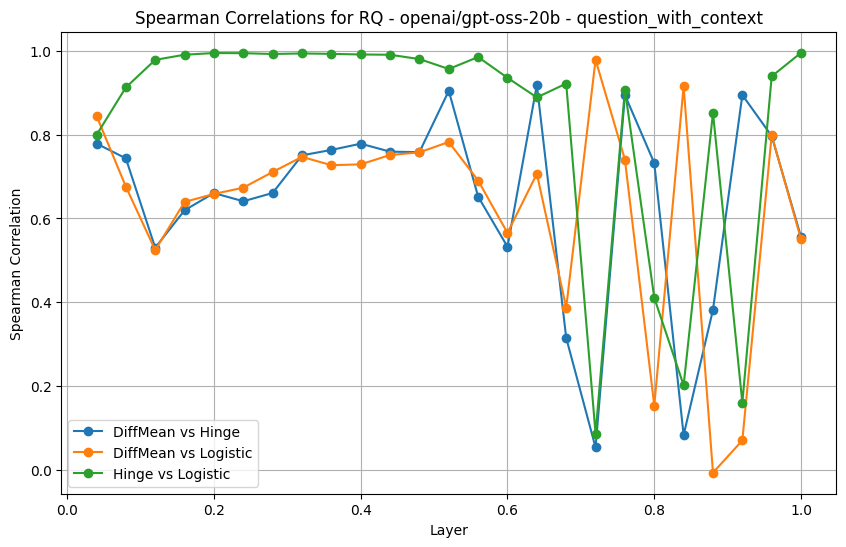

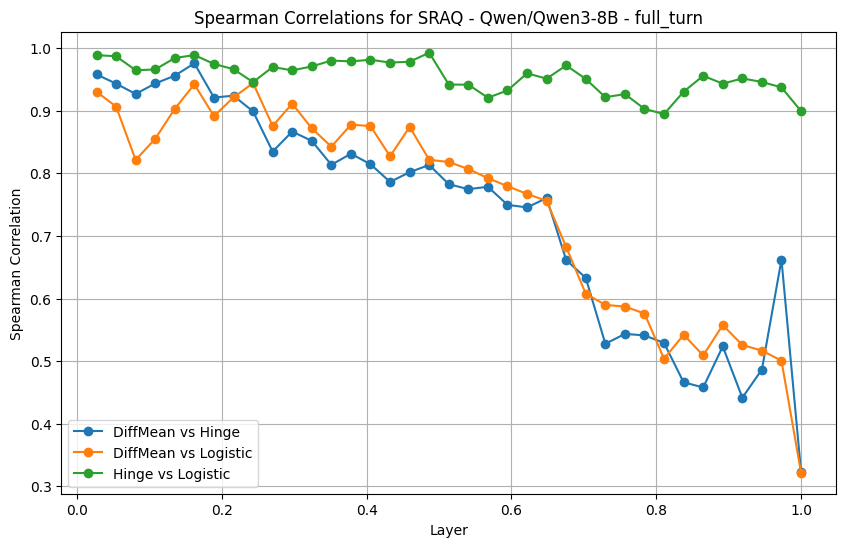

In [7]:
import matplotlib.pyplot as plt
import numpy as np

for result in spearman_corr_real:
    plt.figure(figsize=(10, 6))
    layers = np.arange(1, len(result['diffmean_hinge']) + 1)
    
    layers_norm = layers / layers.max()

    plt.plot(layers_norm, result['diffmean_hinge'], label='DiffMean vs Hinge', marker='o')
    plt.plot(layers_norm, result['diffmean_logistic'], label='DiffMean vs Logistic', marker='o')
    plt.plot(layers_norm, result['hinge_logistic'], label='Hinge vs Logistic', marker='o')

    plt.title(f"Spearman Correlations for {result['benchmark']} - {result['model']} - {result['column']}")
    plt.xlabel('Layer')
    plt.ylabel('Spearman Correlation')
    # plt.ylim(-1, 1)
    # plt.axhline(0, color='gray', linestyle='--')
    plt.legend()
    plt.grid()
    plt.show()